# Classifying Quantum Phases with a Quantum Extreme Learning Machine

*A standalone worked example.* We take the ground state of a many-body
Hamiltonian, push it once through a fixed quantum "reservoir", read out a handful
of low-weight Pauli expectation values, and train **only** a linear classifier on
top. The classifier learns to tell the two phases of matter apart, and its
decision boundary lands on the true quantum critical point, even though it was
never shown an order parameter.

## Motivation: phases, order parameters, and what a QELM changes

A **quantum phase transition** separates two qualitatively different ground
states of a many-body system as a control parameter is tuned at zero temperature.
The textbook way to detect one is to guess an **order parameter**: a specific
observable (say, the magnetization) that is nonzero in one phase and vanishes in
the other. Finding the right order parameter usually requires knowing the physics
of the transition in advance.

A **Quantum Extreme Learning Machine (QELM)** turns this around. It is the
one-shot, static cousin of a quantum reservoir computer:

1. The **input is a quantum state**, here the ground state $|\psi_{\rm gs}(g)\rangle$.
2. A **fixed, untrained** quantum map (a scrambling unitary) spreads the input's
   information across the whole register.
3. We measure a **fixed** bank of simple observables to get a feature vector.
4. Only a **classical linear readout** is trained.

The native advantage over classical machine learning is exactly step 1: the input
can be a genuine quantum state, so no classical description (which would be
exponentially large) is ever needed. The pedagogical punchline of this notebook:
a *generic* scramble-then-measure feature map, with no knowledge of the order
parameter, still separates the phases, and a linear readout on it crosses at the
true critical point.

## Problem statement

**Model.** The transverse-field Ising model (TFIM) on an open chain of $N$ spins,
$$
H(g) = -J\sum_{i} Z_i Z_{i+1} - g \sum_i X_i .
$$
It has a quantum phase transition at $g/J = 1$:

- $g < 1$: **ferromagnetic / ordered** phase (the $ZZ$ coupling dominates).
- $g > 1$: **paramagnetic / disordered** phase (the transverse field dominates).

**Task.** Given only the ground state at a field $g$, decide which phase it is in.

**Constraint.** The classifier is trained on states drawn **far** from the
critical point (clearly ordered or clearly disordered) and is **never told** the
order parameter. We then test it on a dense sweep of $g$ through the critical
region and ask where its decision boundary falls.

**QELM protocol (per input $g$).**
1. Diagonalize $H(g)$, take the ground state $|\psi_{\rm gs}(g)\rangle$.
2. Evolve under a **fixed** nonintegrable scrambling unitary
   $U = e^{-i H_{\rm res} t}$.
3. Read a fixed bank of low-weight Pauli expectation values
   $f_\alpha = \langle \psi_{\rm gs}| U^\dagger O_\alpha U |\psi_{\rm gs}\rangle$.
4. Fit a linear (logistic) readout on $f$ to predict the phase label.

In [1]:
import numpy as np
from scipy.linalg import expm, eigh
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron_op(single, site, N):
    op = np.array([[1.0]], dtype=complex)
    for j in range(N):
        op = np.kron(op, single if j == site else I2)
    return op

### The model Hamiltonian and its ground state

We build $H(g)$ densely (for $N=8$ the Hilbert space is only $2^8 = 256$
dimensional) and take the lowest eigenvector. On an open chain the ground state is
nondegenerate for $g>0$, so this is unambiguous. Note the finite-size ground state
is $\mathbb{Z}_2$-symmetric: the single-site magnetization $\langle Z_i\rangle$ is
**zero in both phases**, so it is useless as a naive order parameter here. The
real signature of order lives in *correlations* $\langle Z_i Z_j\rangle$, which the
QELM never reads directly.

In [2]:
def tfim_hamiltonian(N, J, g):
    """H(g) = -J sum Z_i Z_{i+1} - g sum X_i on an open chain."""
    H = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(N - 1):
        H += -J * (kron_op(Z, i, N) @ kron_op(Z, i + 1, N))
    for i in range(N):
        H += -g * kron_op(X, i, N)
    return H

def ground_state(N, J, g):
    w, v = eigh(tfim_hamiltonian(N, J, g))
    return v[:, 0].astype(complex)

# Sanity check: <Z_0> = 0 in both phases (unbroken Z2), but the
# nearest-neighbour correlation <Z_0 Z_1> is large when ordered, small when not.
N = 8; J = 1.0
for g in (0.3, 1.8):
    psi = ground_state(N, J, g)
    zz = np.vdot(psi, (kron_op(Z, 0, N) @ kron_op(Z, 1, N)) @ psi).real
    z0 = np.vdot(psi, kron_op(Z, 0, N) @ psi).real
    print(f"g={g}:  <Z0>={z0:+.3f}   <Z0 Z1>={zz:+.3f}")

g=0.3:  <Z0>=-0.000   <Z0 Z1>=+0.945


g=1.8:  <Z0>=-0.000   <Z0 Z1>=+0.278


### The fixed reservoir: a scrambling unitary

For the input state to be usefully re-expressed in low-weight observables, the
reservoir must **scramble**: spread local information across the chain. A pure
transverse-field Ising model is Jordan-Wigner integrable and does *not* scramble.
Adding a **longitudinal** field $h_z$ breaks integrability, so the mixed-field
Ising Hamiltonian
$$
H_{\rm res} = J_r \sum_i Z_i Z_{i+1} + h_x \sum_i X_i + h_z \sum_i Z_i
$$
generates genuine scrambling dynamics. We fix its parameters and the evolution
time $t$ **once**; nothing in the reservoir is ever trained.

In [3]:
def mixed_field_ising(N, Jr, hx, hz):
    """Nonintegrable reservoir: Jr sum ZZ + hx sum X + hz sum Z."""
    H = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(N - 1):
        H += Jr * (kron_op(Z, i, N) @ kron_op(Z, i + 1, N))
    for i in range(N):
        H += hx * kron_op(X, i, N) + hz * kron_op(Z, i, N)
    return H

JR, HX, HZ, T_EV = 1.0, 1.05, 0.5, 2.5
U = expm(-1j * mixed_field_ising(N, JR, HX, HZ) * T_EV)   # fixed once
print("scrambling unitary U:", U.shape, " unitary?",
      np.allclose(U.conj().T @ U, np.eye(2**N)))

scrambling unitary U: (256, 256)  unitary? True


### The fixed measurement bank

We read a bank of **low-weight** Pauli observables: all single-site
$\{X_i, Y_i, Z_i\}$ and nearest-neighbour $\{X_iX_{i+1}, Y_iY_{i+1},
Z_iZ_{i+1}\}$. These are exactly the observables one can estimate cheaply on
hardware. For a pure state $\psi$, a Pauli string $P = i^{p} X^{x} Z^{z}$ has
$$
\langle P\rangle = \mathrm{Re}\sum_b \overline{\psi_b}\, W_b\, \psi_{b\oplus x},
$$
an $O(2^N)$ contraction we vectorize over the whole bank at once.

In [4]:
_POP = np.array([bin(i).count('1') for i in range(1 << 16)])
_PH = np.array([1, 1j, -1, -1j])

def pauli_readout(N):
    bit = lambda i: 1 << (N - 1 - i)
    specs, names = [], []
    for i in range(N):
        specs += [(bit(i), 0, 0), (bit(i), bit(i), 1), (0, bit(i), 0)]   # X,Y,Z
        names += [f'X{i}', f'Y{i}', f'Z{i}']
    for i in range(N - 1):
        m = bit(i) | bit(i + 1)
        specs += [(m, 0, 0), (m, m, 2), (0, m, 0)]                       # XX,YY,ZZ
        names += [f'X{i}X{i+1}', f'Y{i}Y{i+1}', f'Z{i}Z{i+1}']
    b = np.arange(1 << N)
    COLS = np.array([b ^ x for (x, z, p) in specs])
    W = np.array([_PH[p] * (1 - 2 * (_POP[z & b] & 1)) for (x, z, p) in specs],
                 dtype=complex)
    return COLS, W, names

COLS, W, names = pauli_readout(N)
print(f"{len(names)} features, e.g. {names[:3]} ... {names[-3:]}")

45 features, e.g. ['X0', 'Y0', 'Z0'] ... ['X6X7', 'Y6Y7', 'Z6Z7']


### The feature map

Putting it together: for each input $g$ we form the ground state, evolve it once
under the fixed $U$, and read the bank. This is the entire "quantum" part of the
learning machine, and none of it depends on the training labels.

In [5]:
def qelm_features(psi_list, U, COLS, W):
    """f_alpha = <psi| U^dag O_alpha U |psi>, evaluated on phi = U psi."""
    F = np.zeros((len(psi_list), COLS.shape[0]))
    for n, psi in enumerate(psi_list):
        phi = U @ psi
        F[n] = np.real(np.conj(phi) * W * phi[COLS]).sum(axis=1)
    return F

### Train far from criticality, test across the transition

We draw training fields **only** from the clearly-ordered ($g \in [0.1, 0.65]$)
and clearly-disordered ($g \in [1.35, 2.4]$) windows, label them $0$/$1$, and hold
out a separate set of clear-region fields to report honest accuracy. The dense
sweep $g \in [0.02, 2.5]$ probes what the readout does in the critical region it
never trained on.

In [6]:
G_TRAIN_ORD = np.linspace(0.10, 0.65, 10)
G_TRAIN_DIS = np.linspace(1.35, 2.40, 10)
G_TEST_ORD  = np.linspace(0.14, 0.61, 8)
G_TEST_DIS  = np.linspace(1.40, 2.35, 8)
G_SWEEP     = np.linspace(0.02, 2.5, 120)

def feats(gs):
    return qelm_features([ground_state(N, J, g) for g in gs], U, COLS, W)

g_train = np.concatenate([G_TRAIN_ORD, G_TRAIN_DIS])
y_train = np.concatenate([np.zeros(len(G_TRAIN_ORD)), np.ones(len(G_TRAIN_DIS))])
g_test  = np.concatenate([G_TEST_ORD, G_TEST_DIS])
y_test  = np.concatenate([np.zeros(len(G_TEST_ORD)), np.ones(len(G_TEST_DIS))])

F_train, F_test, F_sweep = feats(g_train), feats(g_test), feats(G_SWEEP)
print("feature matrices:", F_train.shape, F_test.shape, F_sweep.shape)

feature matrices: (20, 45) (16, 45) (120, 45)


### Train the linear readout

The only trainable object is a logistic-regression readout on the standardized
features. Because the features are **linear in the density matrix** $\rho$, a
linear readout is the well-posed choice: any expectation value the classifier
needs is itself a linear functional of $\rho$, so a linear combination of the
measured features can reproduce it.

In [7]:
scaler = StandardScaler().fit(F_train)
clf = LogisticRegression(C=1.0, max_iter=5000).fit(scaler.transform(F_train), y_train)

acc_train = clf.score(scaler.transform(F_train), y_train)
acc_test  = clf.score(scaler.transform(F_test),  y_test)
prob_sweep = clf.predict_proba(scaler.transform(F_sweep))[:, 1]  # P(disordered)

cross = np.where(np.diff(np.sign(prob_sweep - 0.5)) != 0)[0][0]
p0, p1 = prob_sweep[cross], prob_sweep[cross + 1]
g_cross = G_SWEEP[cross] + (0.5 - p0) / (p1 - p0) * (G_SWEEP[cross + 1] - G_SWEEP[cross])

print(f"train accuracy      = {acc_train:.3f}")
print(f"held-out accuracy   = {acc_test:.3f}")
print(f"decision crossing   = {g_cross:.3f}   (true g_c = 1)")

train accuracy      = 1.000
held-out accuracy   = 1.000
decision crossing   = 0.897   (true g_c = 1)


### Visualize: feature-space geometry and the decision boundary

Panel (a) is a 2D PCA of the feature vectors. The ground states trace out a smooth
one-dimensional manifold parametrized by $g$; the ordered and disordered training
states sit in clearly distinct regions, and the dense sweep threads between them.
Panel (b) shows the trained readout's predicted paramagnetic probability across
the transition. The decision crossing $P=\tfrac12$ lands right at the true
critical point, purely from clear-region training data.

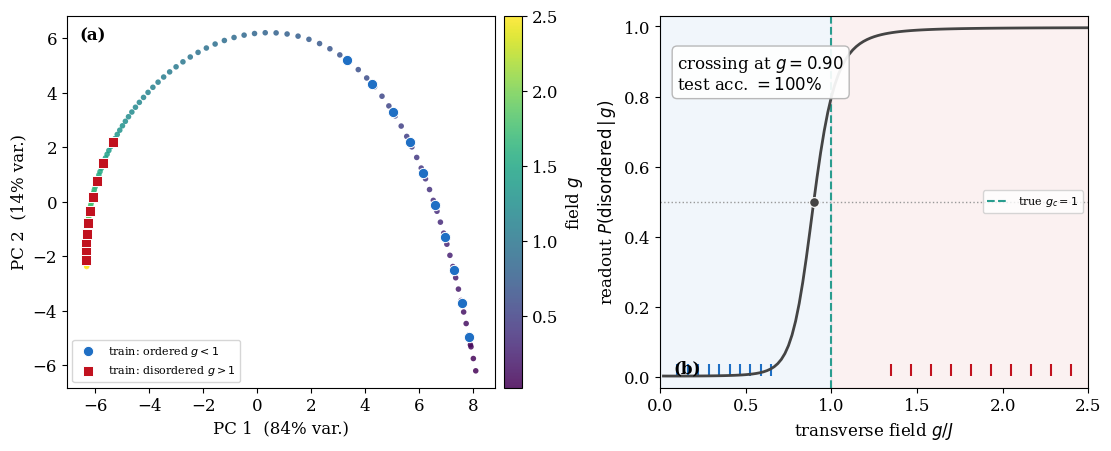

In [8]:
pca = PCA(n_components=2).fit(scaler.transform(F_train))
P_train = pca.transform(scaler.transform(F_train))
P_sweep = pca.transform(scaler.transform(F_sweep))
evr = pca.explained_variance_ratio_

C_ORD, C_DIS, C_SWEEP, C_GC = '#1f6fc4', '#c1121f', '#444444', '#2a9d8f'
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)

ord_m = y_train < 0.5
sc = axa.scatter(P_sweep[:, 0], P_sweep[:, 1], c=G_SWEEP, cmap='viridis',
                 s=16, alpha=0.85, edgecolors='none')
axa.scatter(P_train[ord_m, 0], P_train[ord_m, 1], s=55, color=C_ORD, marker='o',
            edgecolors='white', linewidths=0.7, label='train: ordered $g<1$')
axa.scatter(P_train[~ord_m, 0], P_train[~ord_m, 1], s=55, color=C_DIS, marker='s',
            edgecolors='white', linewidths=0.7, label='train: disordered $g>1$')
axa.set_xlabel(f'PC 1  ({100*evr[0]:.0f}% var.)')
axa.set_ylabel(f'PC 2  ({100*evr[1]:.0f}% var.)')
fig.colorbar(sc, ax=axa, pad=0.02).set_label('field $g$')
axa.legend(loc='lower left', fontsize=8)
axa.text(0.03, 0.97, '(a)', transform=axa.transAxes, fontweight='bold', va='top')

axb.axvspan(0.0, 1.0, color=C_ORD, alpha=0.06)
axb.axvspan(1.0, 2.5, color=C_DIS, alpha=0.06)
axb.axhline(0.5, color='0.6', ls=':', lw=1.0)
axb.axvline(1.0, color=C_GC, ls='--', lw=1.5, label='true $g_c=1$')
axb.plot(G_SWEEP, prob_sweep, color=C_SWEEP, lw=2.0)
axb.plot([g_cross], [0.5], 'o', color=C_SWEEP, ms=7, mec='white', mew=0.8)
axb.scatter(g_train[ord_m], np.full(ord_m.sum(), 0.02), marker='|', s=70, color=C_ORD)
axb.scatter(g_train[~ord_m], np.full((~ord_m).sum(), 0.02), marker='|', s=70, color=C_DIS)
axb.set_xlabel('transverse field $g/J$')
axb.set_ylabel(r'readout $P(\mathrm{disordered}\,|\,g)$')
axb.set_xlim(0, 2.5); axb.set_ylim(-0.03, 1.03)
axb.text(0.04, 0.90, f'crossing at $g={g_cross:.2f}$\ntest acc. $={acc_test*100:.0f}\%$',
         transform=axb.transAxes, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.92))
axb.legend(loc='center right', fontsize=8)
axb.text(0.03, 0.03, '(b)', transform=axb.transAxes, fontweight='bold', va='bottom')
plt.show()

## Discussion

**What happened.** A fixed, untrained quantum scramble turned each ground state
into a feature vector of ordinary low-weight expectation values. A linear readout,
trained only on states far from the transition, learned the boundary between the
two phases and placed it on the true critical point $g_c = 1$. The QELM was never
handed the magnetization or any correlation function to key on. The information
distinguishing the phases is present in the ground state, and a generic scramble
makes it linearly accessible in simple observables.

**Why a *linear* readout is the right choice.** Every feature is
$f_\alpha = \mathrm{Tr}(\rho\, U^\dagger O_\alpha U)$, a **linear** functional of
the state $\rho$. So any quantity that is itself linear in $\rho$, including any
other expectation value, is reachable by a linear combination of the features.
The readout is well posed.

**The caveat (a genuine limit).** A quantity that is a **nonlinear** functional of
$\rho$ cannot be recovered this way. The entanglement entropy
$S = -\mathrm{Tr}(\rho_A \log \rho_A)$ is quadratic-and-worse in $\rho$; no linear
readout on single-copy expectation values can reproduce it, regardless of
training. Detecting order through such nonlinear diagnostics requires multi-copy
protocols (for example SWAP-test / shadow estimators), which is a different tool.
The lesson: the QELM linearizes learning **only** for observables that are already
linear in the state, and phase classification, luckily, is one of them.

**Finite size.** On an open chain of $N=8$ the pseudo-critical point sits slightly
below the thermodynamic $g_c=1$, so the decision crossing appears near $g\approx
0.9$. It sharpens toward $g_c=1$ as $N$ grows.